In [6]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML

sns.set_style("whitegrid")

# Python concatena automáticamente estas cadenas en diferentes
# líneas, escritas así para que el formato en A4 no se
# desborde por la derecha.
url_datos = "datos/queseria_final_tidy.csv"
try:
    df = pd.read_csv(url_datos, 
                     decimal = ",", 
                     sep=';', 
                     encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

In [7]:
df.head()

,fecha,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,cuba_fab_litros,cuba_fab_grasa_g_l,cuba_fab_prot_g_l,stock_cierre_litros,queso_kg,queso_est_pct,queso_mg_pct,suero_litros,suero_grasa_g_l,suero_prot_g_l,suero_es_g_l
0,31/12/2023,4976,4831,40.65,36.63,0,0.00,0.00,4831,0.00,0.00,0.00,0.0,0.00,0.00,0.00
1,01/01/2024,4659,4523,43.65,34.37,5028,40.25,34.16,4354,673.15,50.13,26.38,4396.0,5.54,3.79,59.34
2,02/01/2024,5314,5159,41.62,34.76,5026,40.02,33.38,4513,592.37,53.52,27.85,4473.0,7.99,7.01,65.31
3,03/01/2024,5454,5295,42.56,34.06,5018,40.51,33.04,4808,598.68,53.91,27.32,4458.0,8.71,6.17,66.50
4,04/01/2024,5082,4934,40.76,36.37,5018,39.35,33.87,4742,645.86,51.99,25.65,4412.0,7.07,3.66,61.00


In [8]:
# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y', # Formato Día/Mes/Año confirmado
    errors='coerce'    # convierte los valores que no puede leer a NaT
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

In [9]:
# Reemplazamos todos los 0 por NaN
df = df.replace(0, np.nan)

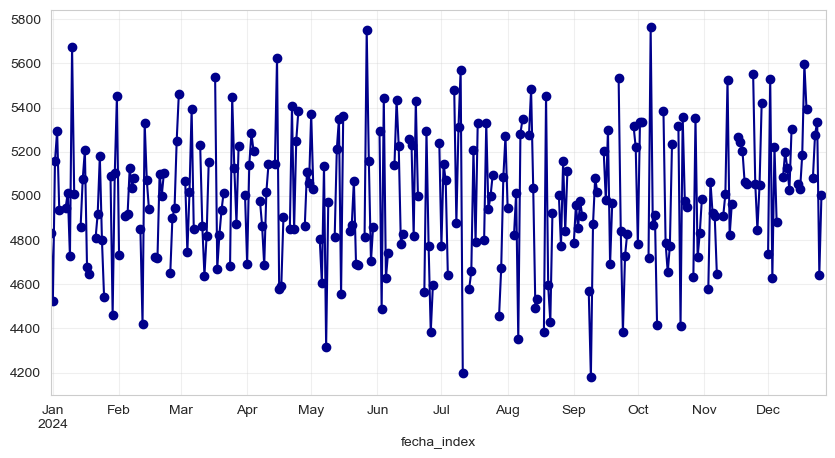

In [10]:
# Visualización
plt.figure(figsize=(8, 4))

df['entrada_litros'].plot(kind='line', marker='o', figsize=(10, 5), color='darkblue')
plt.grid(True, alpha=0.3)
plt.show()

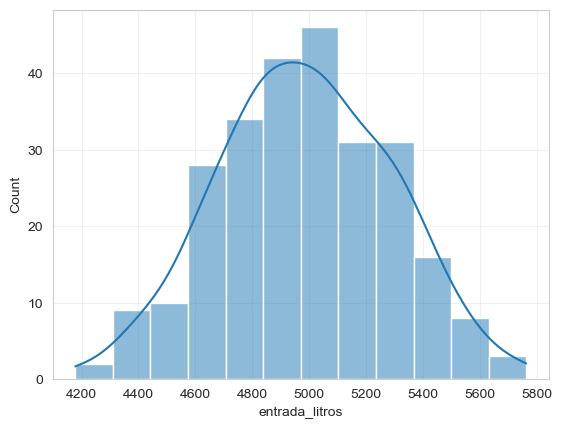

In [11]:
# Visualización
# plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='entrada_litros', kde=True)
plt.grid(True, alpha=0.3)
plt.show()

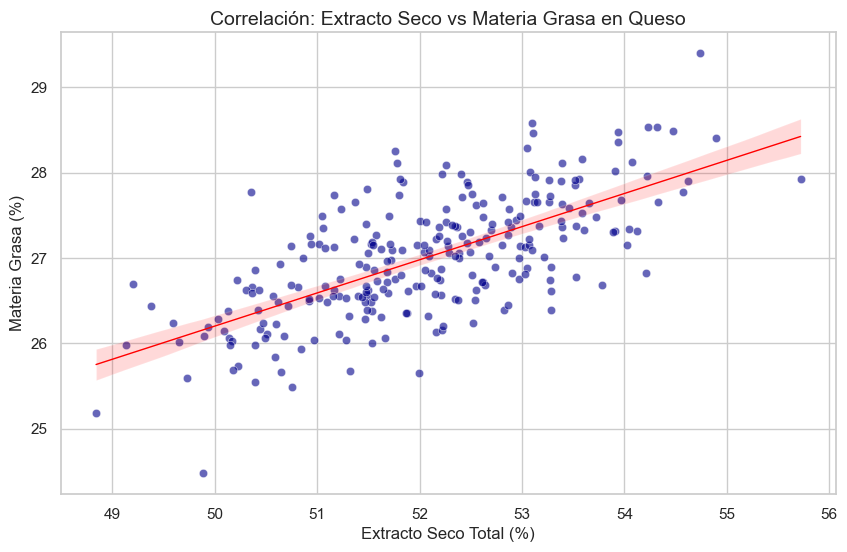

In [12]:
# 1. Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de dispersión (XY)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='queso_est_pct', 
    y='queso_mg_pct', 
    alpha=0.6,          # Transparencia para ver puntos solapados
    color='darkblue'
)

# 3. Añadimos una línea de tendencia (opcional pero muy útil)
sns.regplot(
    data=df, 
    x='queso_est_pct', 
    y='queso_mg_pct', 
    scatter=False,      # No dibuja los puntos otra vez
    color='red', 
    line_kws={"linewidth": 1}
)

# 4. Etiquetas y título
plt.title('Correlación: Extracto Seco vs Materia Grasa en Queso', fontsize=14)
plt.xlabel('Extracto Seco Total (%)')
plt.ylabel('Materia Grasa (%)')

plt.show()

In [13]:
df['rendim_l_kg'] = df['cuba_fab_litros']/df['queso_kg']

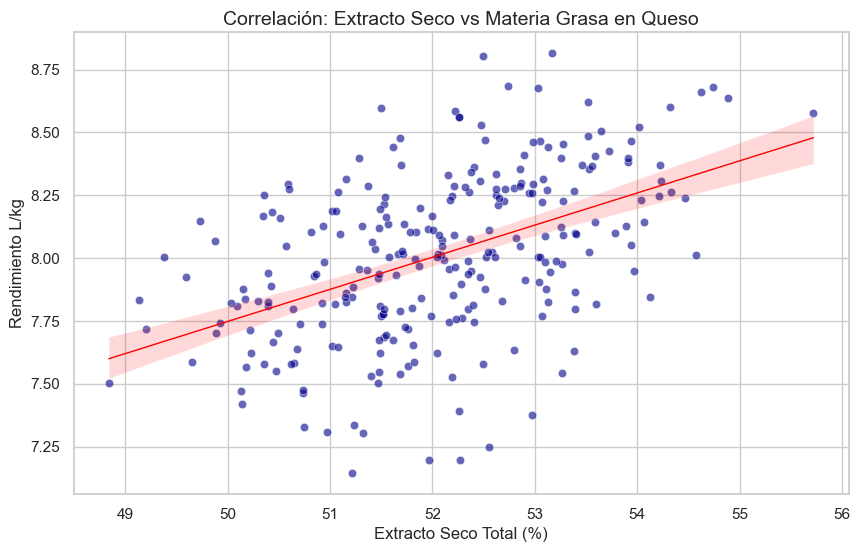

In [14]:
# 1. Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de dispersión (XY)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='queso_est_pct', 
    y='rendim_l_kg', 
    alpha=0.6,          # Transparencia para ver puntos solapados
    color='darkblue'
)

# 3. Añadimos una línea de tendencia (opcional pero muy útil)
sns.regplot(
    data=df, 
    x='queso_est_pct', 
    y='rendim_l_kg', 
    scatter=False,      # No dibuja los puntos otra vez
    color='red', 
    line_kws={"linewidth": 1}
)

# 4. Etiquetas y título
plt.title('Correlación: Extracto Seco vs Materia Grasa en Queso', fontsize=14)
plt.xlabel('Extracto Seco Total (%)')
plt.ylabel('Rendimiento L/kg')

plt.show()